In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from IPython.display import clear_output
from dataclasses import replace

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, measure,
                            plotting, analysis, multicat, selection, core, stack)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins
from utils_lya_halo.stack import build_stacks

LYA_REST = 1215.67

# Reading in output and stacking

In [10]:
random_seed = 10
split_col = 'z'
control_col = 'MASS_50'
col_cut = True
bin_mode = 'kpc'
half_width = 3.5
vr_approx = 90
stack_method = 'biweight'
rest_wave_min = 1100
rest_wave_max = 1300
spexlim = (rest_wave_min, rest_wave_max)
n_bootstrap = 500


if (col_cut):
    labelling=(f"low-{split_col}", f"high-{split_col}")
else:
    labelling=(f"Sample 1", f"Sample 2")

cfg_prod = replace(cfg,
                   field='BOTH',
                   bin_mode=bin_mode,
                   rest_wave_min=rest_wave_min,
                   rest_wave_max=rest_wave_max,
                   n_bootstrap=n_bootstrap,
                   #flux_unit='flux_arcsec2',
                   #rest_density=False,
                   line_window=[LYA_REST-half_width, LYA_REST+half_width])

# load and cut your mega-product as normal
if (bin_mode.lower() == 'virial'):
    product1 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits')
    product2 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits')
elif (bin_mode.lower() == 'kpc'):
    product1 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_87bd55_AEGIS_MOSDEF_kpc_biweight_image_bg57-63.fits')
    product2 = read_galaxy_fits('./outputs/galaxy_catc1488c_b8_87bd55_COSMOS_MOSDEF_kpc_biweight_image_bg57-63.fits')
else:
    print('Wrong input or \'other\' not yet implemented')

product1 = apply_finite_cut(product1, cfg_prod.cut_radial_bin, cfg_prod.min_good_wave)
product2 = apply_finite_cut(product2, cfg_prod.cut_radial_bin, cfg_prod.min_good_wave)

# combine into one product -- tags each galaxy with its source in column "SUBSET"
mega = multicat.combine_products(
    {"cat1": product1, "cat2": product2},
    label_col="SUBSET")

Finite-spectrum cut (bin 7, > 100 px): kept 230 / 248 galaxies
Finite-spectrum cut (bin 7, > 100 px): kept 276 / 280 galaxies
combined 2 products -> 506 galaxies (origin in column 'SUBSET')


/tmp/ipykernel_18387/1889832685.py:4: RuntimeWarning: invalid value encountered in log10
  edges=[10**((np.log10(ssfr[np.isfinite(ssfr)])).mean())],  # or your boundary


<Axes: title={'center': 'Split quantity distribution'}, xlabel='sSFR', ylabel='galaxies'>

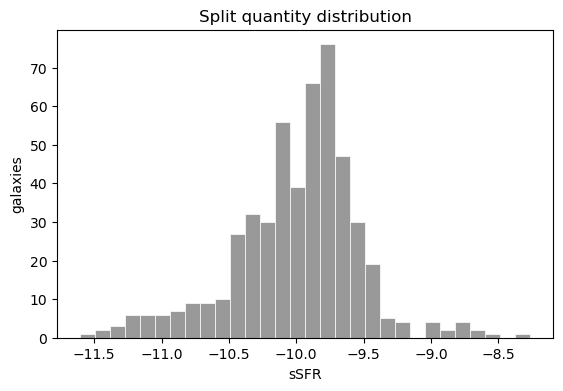

In [3]:
# see the distribution + where it split (log axis for sSFR):
ssfr = selection.derive(mega, "SFR100_50 / 10**MASS_50")
selection.plot_split_hist(mega, "SFR100_50 / 10**MASS_50",
                    edges=[10**((np.log10(ssfr[np.isfinite(ssfr)])).mean())],  # or your boundary
                    log=True, xlabel="sSFR")

Column Split:

In [24]:
split_halves = multicat.split_product_by(
    mega,
    column=split_col,
    percentiles=50,             # scalar -> two bins: 0-50% and 50-100%
    labels=["low", "high"])

low  = split_halves["low"]
high = split_halves["high"]

stacks1 = build_stacks(cfg_prod, low, keep_cube=True)
stacks2 = build_stacks(cfg_prod, high, keep_cube=True)

clear_output()
print(low.ngal, high.ngal)

231 275


Cone Search:

In [5]:
# hit = selection.cone_search(mega, ra=150.12, dec=2.30, radius_arcsec=30)
# print(hit)                 # <Selection 7/512 galaxies, sep 2.1-28.7">
# hit.catalog               # matched rows, nearest first, with a 'sep_arcsec' column

# st = multicat.build_stacks(cfg_prod, hit.product)   # hit.product is stack-ready

# selection.plot_sky(mega, hit, center=(150.12, 2.30), radius_arcsec=30)

Different Halo Catalog

In [6]:
# file_name1 = './outputs/galaxy_cat11f6d7_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits'
# file_name2 = './outputs/galaxy_cat11f6d7_b7_661367_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits'

# products = multicat.load_products(
#     [
#         {"label": "cat1", "path": file_name1},
#         {"label": "cat2", "path": file_name2},
#     ],
#     base_config=cfg,      # supplies cut_radial_bin / min_good_wave for the finite cut
#     apply_cut=True,
# )

# stacks = multicat.stack_each(cfg, products, keep_cube=True)
# stacks_cat1 = stacks["cat1"]
# stacks_cat2 = stacks["cat2"]

Selection Cuts:

In [7]:
# s = selection.select_by(mega, "(z < 3.5)") #Include selection cuts like (SUBSET == 'cat1') & (z < 2.5)

# halves = selection.split_by_derived(s.product, "SFR100_50 / 10**MASS_50",
#                                          name="SSFR100_50", percentiles=50,
#                                          labels=["low", "high"])

Mask Input

In [8]:
# categorical works too: an array of strings/ints -> one group per unique value
#my_mask = (mega.catalog["z"] < 2.75) & np.ones_like(mega.catalog["z"]).astype('bool')
#my_mask = (mega.catalog["MASS_50"] > 9.9) & (mega.catalog["MASS_50"] < 11.1)
# my_mask = (mega.catalog["MASS_50"] > 10.5)

# groups = selection.split_by_mask(mega, my_mask, labels=["cold", "hot"])

# g1 = groups['cold']
# g2 = groups['hot']

# stacks1 = build_stacks(cfg_prod, g1, keep_cube=True)
# stacks2 = build_stacks(cfg_prod, g2, keep_cube=True)

Controlled Column Split

In [36]:
low_mask, high_mask = selection.split_controlled(mega.catalog,
                                       split_col=split_col,
                                       control_col=control_col,
                                       n_control_bins=5)

labels = np.full(len(mega.catalog), "skip", dtype="U4")
labels[low_mask], labels[high_mask] = "low", "high"
groups = selection.split_by_mask(mega, labels)
g_low, g_high = groups["low"], groups["high"]

stacks1  = build_stacks(cfg_prod, g_low,  keep_cube=True) #LOW
stacks2 = build_stacks(cfg_prod, g_high, keep_cube=True)  #HIGH

  MASS_50 [8.21,9.58):  99 gal  low=49  high=50
  MASS_50 [9.58,9.82): 100 gal  low=50  high=50
  MASS_50 [9.82,10.1): 102 gal  low=51  high=51
  MASS_50 [10.1,10.4): 103 gal  low=52  high=51
  MASS_50 [10.4,11.7): 102 gal  low=51  high=51

z split at fixed MASS_50 (median):
  low :  253 gal,  median MASS_50=9.91,  median z=2.19
  high:  253 gal,  median MASS_50=9.93,  median z=2.57
  MASS_50 offset between halves: 0.02  (want ~0)
  high: 253 galaxies
  low: 253 galaxies


Capping logMstar 11.37 -> 11.00, z=2.163
Capping logMstar 11.01 -> 11.00, z=2.296
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.04 -> 11.00, z=2.187
Capping logMstar 11.18 -> 11.00, z=2.292
Capping logMstar 11.18 -> 11.00, z=2.114
Capping logMstar 11.29 -> 11.00, z=2.191
Capping logMstar 11.43 -> 11.00, z=2.102


Capping logMstar 11.21 -> 11.00, z=2.471
Capping logMstar 11.28 -> 11.00, z=2.365
Capping logMstar 11.07 -> 11.00, z=2.475
Capping logMstar 11.06 -> 11.00, z=2.562
Capping logMstar 11.11 -> 11.00, z=2.442
Capping logMstar 11.74 -> 11.00, z=2.447
Capping logMstar 11.23 -> 11.00, z=2.465
Capping logMstar 11.19 -> 11.00, z=2.468
Capping logMstar 11.06 -> 11.00, z=2.472
Capping logMstar 11.06 -> 11.00, z=2.479
Capping logMstar 11.23 -> 11.00, z=2.471
Capping logMstar 11.63 -> 11.00, z=2.487
Capping logMstar 11.30 -> 11.00, z=2.446
Capping logMstar 11.08 -> 11.00, z=3.179


Separate Catalog Column - Lya Class Separation

In [9]:
# prod_egs = core.read_core_fits("6-23-26-core_extraction_egs_MF.fits")
# prod_cosmos = core.read_core_fits("6-23-26-core_extraction_cosmos_MF.fits")
# prod_core = stack.concat_core_prods(prod_egs, prod_cosmos)

# # --- build CLASS on prod_core's full axis (notebook-specific bookkeeping) ---
# cat_core = prod_core['catalog']
# labels = np.asarray(prod_core['results']['label'], dtype=object).copy()
# labels[np.asarray(cat_core['AGN_FLAG'], dtype=bool)] = 'AGN'   # AGN overrides
# labels[~np.asarray(cat_core['KEEP'],     dtype=bool)] = ''     # non-KEEP -> unclassified
# ext = cat_core.copy()
# ext['CLASS'] = labels

# # --- carry CLASS onto mega by position, then split: two calls ---
# mega2 = multicat.add_matched_column(mega, ext, 'CLASS', radius_arcsec=0.1)

# idx, sep, matched = multicat.match_catalog(mega, ext, radius_arcsec=0.1)
# print(f"{matched.sum()}/{mega.ngal} matched; median sep {np.nanmedian(sep):.3f}\"")

# groups = multicat.split_product_by(
#     mega2, 'CLASS',
#     groups=[['AGN'], ['LAE'], ['emitter'], ['null'], ['absorber'],
#             ['LAE', 'emitter'], ['null', 'absorber']],
#     labels=['AGN', 'LAE', 'emitter', 'null', 'absorber', 'bright', 'dim'])

# print({k: v.ngal for k, v in groups.items()})

In [10]:
# agn = groups['AGN']
# lae = groups['LAE']
# emitter = groups['emitter']
# null = groups['null']
# absorber = groups['absorber']
# bright = groups['bright']
# dim = groups['dim']

# stacks1 = build_stacks(cfg_prod, agn, keep_cube=True)
# stacks2 = build_stacks(cfg_prod, lae, keep_cube=True)
# stacks3 = build_stacks(cfg_prod, emitter, keep_cube=True)
# stacks4 = build_stacks(cfg_prod, null, keep_cube=True)
# stacks5 = build_stacks(cfg_prod, absorber, keep_cube=True)
# stacks6 = build_stacks(cfg_prod, bright, keep_cube=True)
# stacks7 = build_stacks(cfg_prod, dim, keep_cube=True)

# clear_output()

# Simple Plotting and Measurements

In [13]:
# all radial bins, both half-stacks on one figure
plotting.plot_stack_panels_two(stacks, stacks2,
                               method=stack_method,
                               distance_type=bin_mode,
                               labels=labelling,
                               layout="overlay",
                               xlim=(1180, 1300),
                               lya_window=half_width)
plotting.plot_stack_panels_two(stacks1, stacks2,
                               method=stack_method,
                               distance_type=bin_mode,
                               labels=labelling,
                               layout="side",
                               xlim=(1180, 1300),
                               lya_window=half_width)

ValueError: stacks have different nrad (8 vs 10); they must share r_edges.

In [37]:
#Run bootstrap
boot1 = analysis.run_measurement_suite(cfg_prod, stacks1)
boot2 = analysis.run_measurement_suite(cfg_prod, stacks2)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-10: v=+84.9  σ=367.3  skew=-0.406
  10-20: v=+74.9  σ=418.3  skew=-0.249
  20-50: v=-39.1  σ=381.4  skew=-0.008
  50-100: v=+67.2  σ=302.6  skew=+0.141
  100-200: v=+44.5  σ=272.2  skew=-0.066
  200-500: v=+69.5  σ=188.1  skew=-0.158
  500-1000: v=+36.4  σ=238.0  skew=-0.309
  1000-2000: v=+115.4  σ=288.7  skew=-0.530


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-10: v=+200.7  σ=327.4  skew=-0.620
  10-20: v=+78.4  σ=374.3  skew=-0.485
  20-50: v=-5.0  σ=338.6  skew=-0.126
  50-100: v=-2.6  σ=279.8  skew=+0.018
  100-200: v=-41.6  σ=275.3  skew=-0.183
  200-500: v=-23.8  σ=297.3  skew=-0.442
  500-1000: v=+7.4  σ=314.8  skew=-0.004
  1000-2000: v=+150.4  σ=319.3  skew=+0.258


In [ ]:
# multicat.compare_centroids(boots,
#                            bin_mode=cfg.bin_mode,
#                            ylims=(-300, 300),
#                            xlims=(0.03, 30))

In [38]:
#Inspect results
print('-------')
analysis.print_centroid_table(boot1)
analysis.compare_centroid_methods(stacks1)
print('-------')
analysis.print_centroid_table(boot2)
analysis.compare_centroid_methods(stacks2)
print('-------')

-------
       bin    v_fid           [lo,hi]    ok%     B/R    σ_kms     skew
──────────────────────────────────────────────────────────────────────
      0-10   +147.4  [+105.8,+181.3]   100%   0.539    367.3   -0.406
     10-20   +144.6  [+110.1,+174.6]   100%   0.661    418.3   -0.249
     20-50    -26.4  [ -72.5, +22.3]   100%   1.133    381.4   -0.008
    50-100    +53.5  [ -19.8,+129.1]   100%   0.274    302.6   +0.141
   100-200    +49.4  [ -61.4,+131.6]   100%   0.948    272.2   -0.066
   200-500    +70.1  [ +17.6,+117.3]   100%   0.870    188.1   -0.158
  500-1000    +68.4  [ -21.5,+130.6]   100%   0.735    238.0   -0.309
 1000-2000   +185.9  [ +83.2,+259.5]   100%   0.222    288.7   -0.530
                  method |       0-10      10-20      20-50     50-100    100-200    200-500   500-1000  1000-2000
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 flux-weighted (clipped) |      +93.5      +88.3      -15.0 

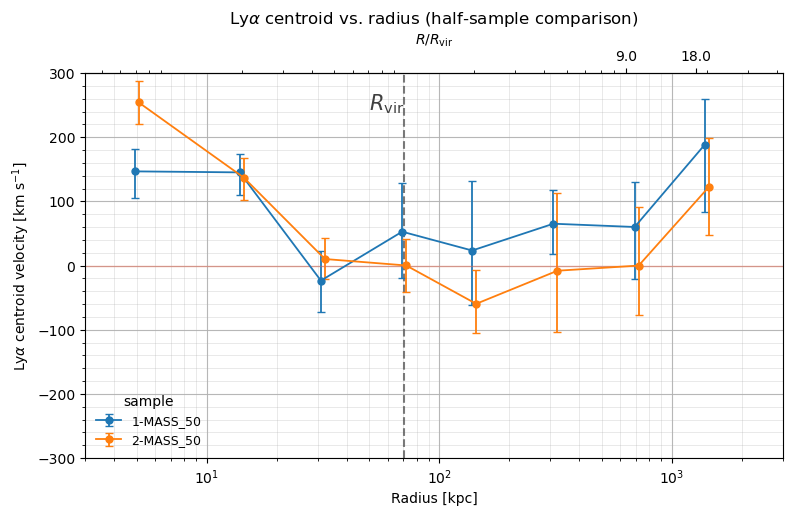

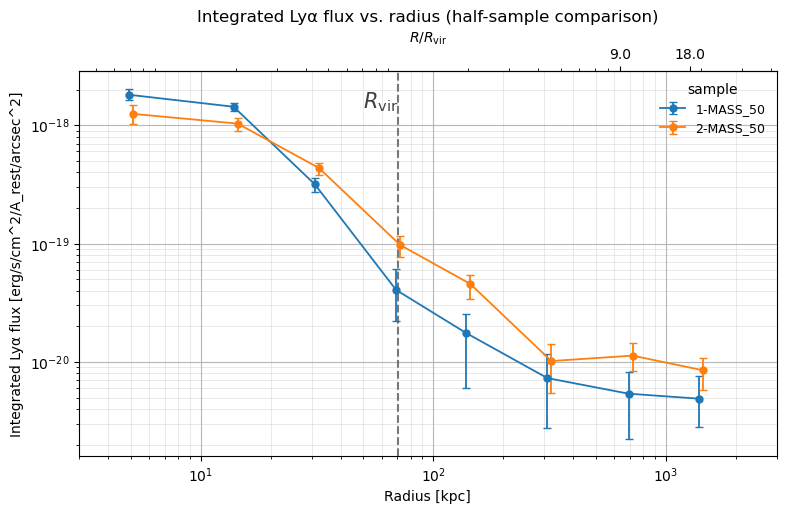

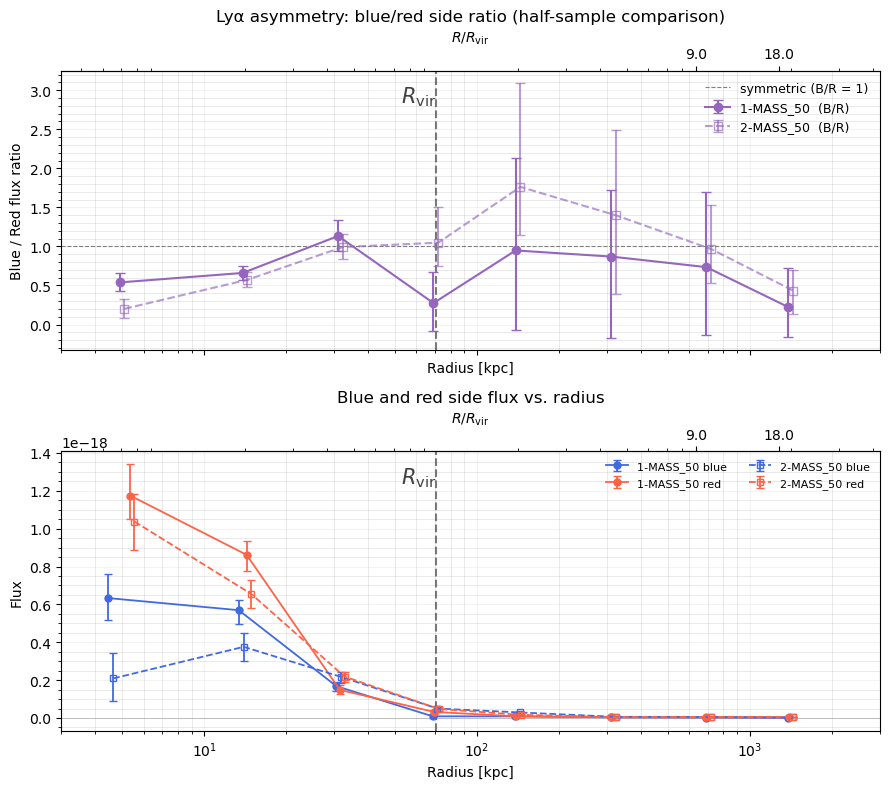

(<Figure size 900x800 with 2 Axes>,
 (<Axes: title={'center': 'Lyα asymmetry: blue/red side ratio (half-sample comparison)'}, xlabel='Radius [kpc]', ylabel='Blue / Red flux ratio'>,
  <Axes: title={'center': 'Blue and red side flux vs. radius'}, xlabel='Radius [kpc]', ylabel='Flux'>))

In [39]:
if (scale.lower() == 'kpc'):
    xlims = (3, 3000)
    vr_ticks = (vr_approx/10, vr_approx/5, vr_approx/2, vr_approx, vr_approx*2, vr_approx*5, vr_approx*10, vr_approx*20)
elif (scale.lower() == 'virial'):
    xlims = (0.03, 30)
else:
    print('NOOO')

# the three profiles, both samples per figure
analysis.plot_centroid_profile_two(boot1, boot2, stacks1, stacks2,
                                    labels=(f"1-{split_col}", f"2-{split_col}"),
                                    xlims=xlims,
                                    vr_ticks=vr_ticks,
                                    ylims=(-300, 300),
                                    bin_mode=scale,
                                    figsize=(9, 5))
analysis.plot_flux_profile_two(boot1, boot2, stacks1, stacks2,
                                    labels=(f"1-{split_col}", f"2-{split_col}"),
                                    xlims=xlims,
                                    vr_ticks=vr_ticks,
                                    bin_mode=scale,
                                    ylims=None,
                                    figsize=(9, 5))
analysis.plot_asymmetry_profile_two(boot1, boot2, stacks1, stacks2,
                                    labels=(f"1-{split_col}", f"2-{split_col}"),
                                    xlims=xlims,
                                    vr_ticks=vr_ticks,
                                    bin_mode=scale,
                                    figsize=(9, 8))